# Predict preferred variables from RF map

## Load and align data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import shift
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import r2_score, confusion_matrix

RESULTS_DIR = Path(r"C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ephys\results")

rf_df   = pd.read_csv(RESULTS_DIR / "ephys_rf_unit_info.csv")
pref_df = pd.read_csv(RESULTS_DIR / "ephys_pref_variables.csv")

# Merge on unit_id
df = rf_df[['unit_id', 'rf_map_path']].merge(
    pref_df[['unit_id', 'pref_sf_gaussian_snapped', 'pref_tf_gaussian_snapped', 'pref_ori']],
    on='unit_id', how='inner'
).dropna(subset=['rf_map_path'])

print(f"Units after merge: {len(df)}")
print(df[['pref_sf_gaussian_snapped', 'pref_tf_gaussian_snapped', 'pref_ori']].describe())

Units after merge: 20374
       pref_sf_gaussian_snapped  pref_tf_gaussian_snapped      pref_ori
count              20374.000000              20374.000000  20374.000000
mean                   0.121576                  4.566752     63.493423
std                    0.108915                  4.789245     49.327675
min                    0.020000                  1.000000      0.000000
25%                    0.040000                  1.000000      0.000000
50%                    0.080000                  2.000000     45.000000
75%                    0.160000                  8.000000     90.000000
max                    0.320000                 15.000000    135.000000


## Load and center-align RF maps

In [2]:
def center_align_rf(rf_flat, rf_side):
    rf_2d  = rf_flat.reshape(rf_side, rf_side)
    peak   = np.unravel_index(np.argmax(rf_2d), rf_2d.shape)
    center = (rf_side // 2, rf_side // 2)
    delta  = (center[0] - peak[0], center[1] - peak[1])
    return shift(rf_2d, shift=delta, mode='constant', cval=0.0).ravel()

rf_maps, valid_idx = [], []
for i, row in df.iterrows():
    try:
        rf_maps.append(np.load(row['rf_map_path'])['rf'].ravel())
        valid_idx.append(i)
    except Exception:
        pass

df = df.loc[valid_idx].reset_index(drop=True)
rf_maps = np.array(rf_maps, dtype=np.float32)

rf_side = int(np.round(np.sqrt(rf_maps.shape[1])))
print(f"RF map size: {rf_side}x{rf_side},  units: {len(rf_maps)}")

# Center-align
X = np.array([center_align_rf(r, rf_side) for r in rf_maps], dtype=np.float32)
print(f"X shape: {X.shape}")

RF map size: 9x9,  units: 20374
X shape: (20374, 81)


## Make scatter plot

In [6]:
mask = (
    (rf_df["rf_center_x"] != 40) & (rf_df["rf_center_x"] != -40) &
    (rf_df["rf_center_y"] != 40) & (rf_df["rf_center_y"] != -40) &
    (rf_df["rf_r_squared"] >= 0.5)
)

rf_df_filtered = rf_df[mask]
print(f"Filtered RF info shape: {rf_df_filtered.shape}")

pref_df_filtered = pref_df[mask]
print(f"Filtered pref info shape: {pref_df_filtered.shape}")

Filtered RF info shape: (3873, 17)
Filtered pref info shape: (3873, 21)


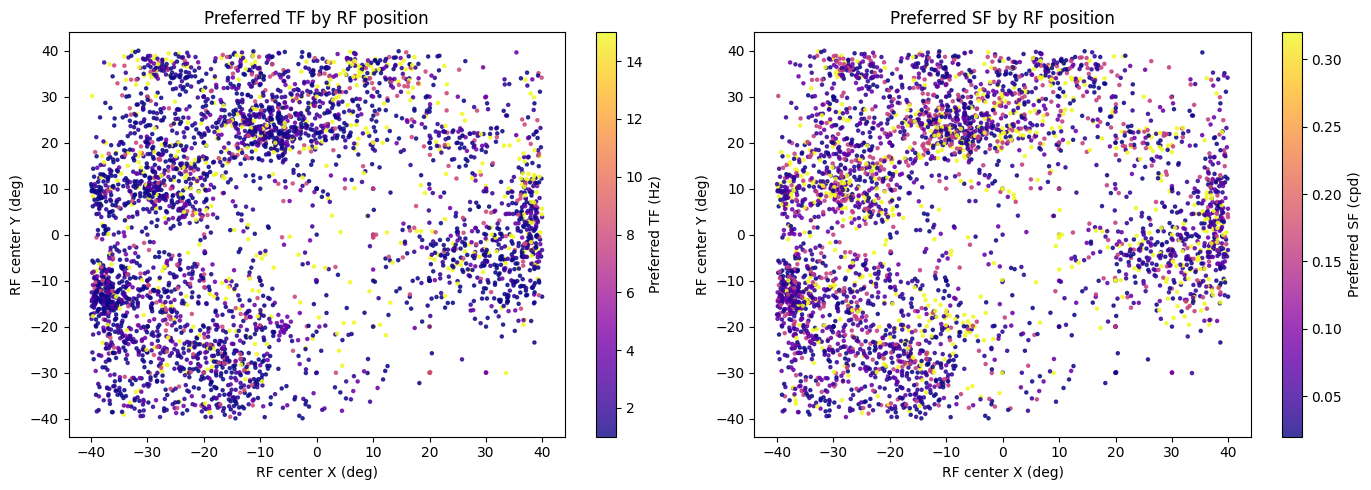

In [13]:
rf_x = rf_df_filtered['rf_center_x'].values
rf_y = rf_df_filtered['rf_center_y'].values
pref_tf_vals = pref_df_filtered['pref_tf_gaussian_snapped'].values
pref_sf_vals = pref_df_filtered['pref_sf_gaussian_snapped'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(rf_x, rf_y, c=pref_tf_vals, cmap='plasma', s=5, alpha=0.8, rasterized=True)
plt.colorbar(sc0, ax=axes[0], label='Preferred TF (Hz)')
axes[0].set_xlabel('RF center X (deg)')
axes[0].set_ylabel('RF center Y (deg)')
axes[0].set_title('Preferred TF by RF position')

sc1 = axes[1].scatter(rf_x, rf_y, c=pref_sf_vals, cmap='plasma', s=5, alpha=0.8, rasterized=True)
plt.colorbar(sc1, ax=axes[1], label='Preferred SF (cpd)')
axes[1].set_xlabel('RF center X (deg)')
axes[1].set_ylabel('RF center Y (deg)')
axes[1].set_title('Preferred SF by RF position')

fig.tight_layout()
plt.show()


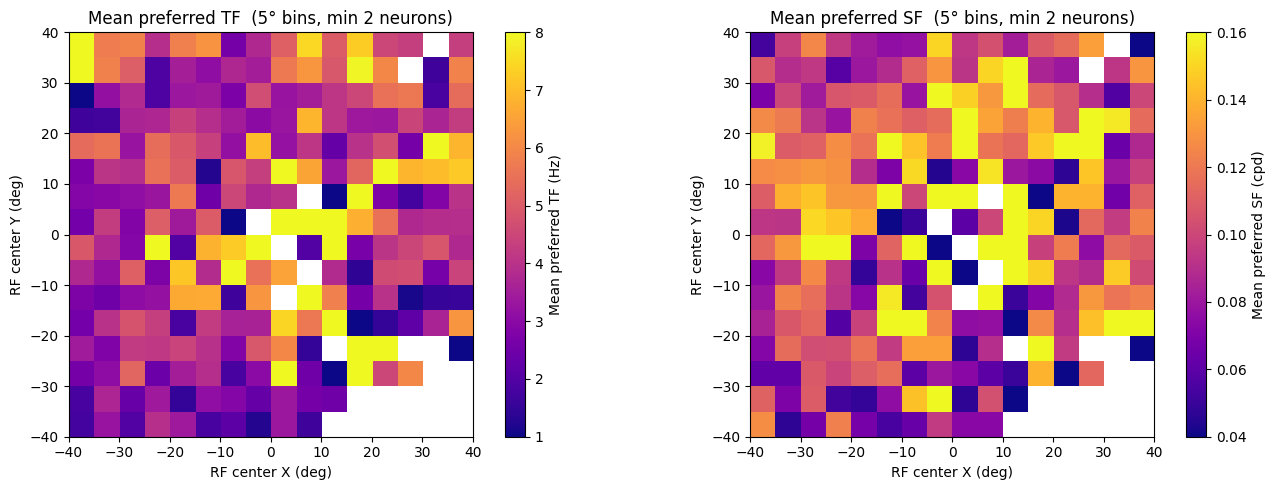

In [30]:
BIN_DEG     = 5           # bin size in degrees
TF_CLIM     = (1, 8)    # (min, max) Hz  — set to None to use data range
SF_CLIM     = (0.04, 0.16)  # (min, max) cpd — set to None to use data range
MIN_SAMPLES = 2           # bins with fewer neurons are left as NaN

x_bins = np.arange(np.floor(rf_x.min()), np.ceil(rf_x.max()) + BIN_DEG, BIN_DEG)
y_bins = np.arange(np.floor(rf_y.min()), np.ceil(rf_y.max()) + BIN_DEG, BIN_DEG)

xi = np.digitize(rf_x, x_bins) - 1
yi = np.digitize(rf_y, y_bins) - 1

n_xb, n_yb = len(x_bins) - 1, len(y_bins) - 1
mean_tf = np.full((n_yb, n_xb), np.nan)
mean_sf = np.full((n_yb, n_xb), np.nan)

for iy in range(n_yb):
    for ix in range(n_xb):
        mask = (xi == ix) & (yi == iy)
        if mask.sum() >= MIN_SAMPLES:
            mean_tf[iy, ix] = np.nanmean(pref_tf_vals[mask])
            mean_sf[iy, ix] = np.nanmean(pref_sf_vals[mask])

extent = [x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(mean_tf, origin='lower', extent=extent, aspect='equal',
                     cmap='plasma',
                     vmin=TF_CLIM[0] if TF_CLIM else None,
                     vmax=TF_CLIM[1] if TF_CLIM else None)
plt.colorbar(im0, ax=axes[0], label='Mean preferred TF (Hz)')
axes[0].set_xlabel('RF center X (deg)')
axes[0].set_ylabel('RF center Y (deg)')
axes[0].set_title(f'Mean preferred TF  ({BIN_DEG}° bins, min {MIN_SAMPLES} neurons)')

im1 = axes[1].imshow(mean_sf, origin='lower', extent=extent, aspect='equal',
                     cmap='plasma',
                     vmin=SF_CLIM[0] if SF_CLIM else None,
                     vmax=SF_CLIM[1] if SF_CLIM else None)
plt.colorbar(im1, ax=axes[1], label='Mean preferred SF (cpd)')
axes[1].set_xlabel('RF center X (deg)')
axes[1].set_ylabel('RF center Y (deg)')
axes[1].set_title(f'Mean preferred SF  ({BIN_DEG}° bins, min {MIN_SAMPLES} neurons)')

fig.tight_layout()
plt.show()


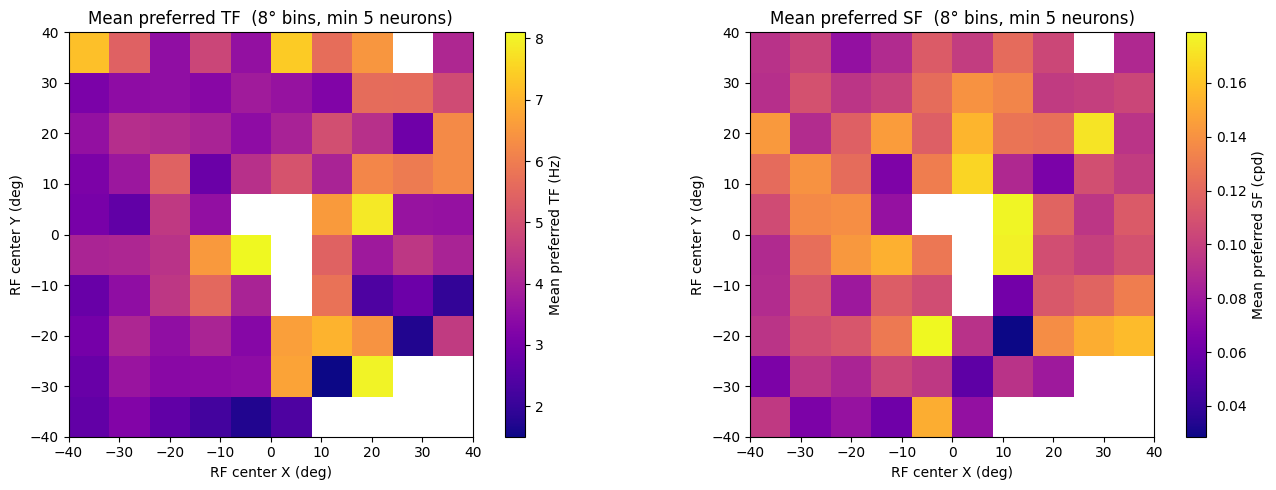

In [23]:
BIN_DEG     = 8           # bin size in degrees
TF_CLIM     = None    # (min, max) Hz  — set to None to use data range
SF_CLIM     = None  # (min, max) cpd — set to None to use data range
MIN_SAMPLES = 5           # bins with fewer neurons are left as NaN

x_bins = np.arange(np.floor(rf_x.min()), np.ceil(rf_x.max()) + BIN_DEG, BIN_DEG)
y_bins = np.arange(np.floor(rf_y.min()), np.ceil(rf_y.max()) + BIN_DEG, BIN_DEG)

xi = np.digitize(rf_x, x_bins) - 1
yi = np.digitize(rf_y, y_bins) - 1

n_xb, n_yb = len(x_bins) - 1, len(y_bins) - 1
mean_tf = np.full((n_yb, n_xb), np.nan)
mean_sf = np.full((n_yb, n_xb), np.nan)

for iy in range(n_yb):
    for ix in range(n_xb):
        mask = (xi == ix) & (yi == iy)
        if mask.sum() >= MIN_SAMPLES:
            mean_tf[iy, ix] = np.nanmean(pref_tf_vals[mask])
            mean_sf[iy, ix] = np.nanmean(pref_sf_vals[mask])

extent = [x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(mean_tf, origin='lower', extent=extent, aspect='equal',
                     cmap='plasma',
                     vmin=TF_CLIM[0] if TF_CLIM else None,
                     vmax=TF_CLIM[1] if TF_CLIM else None)
plt.colorbar(im0, ax=axes[0], label='Mean preferred TF (Hz)')
axes[0].set_xlabel('RF center X (deg)')
axes[0].set_ylabel('RF center Y (deg)')
axes[0].set_title(f'Mean preferred TF  ({BIN_DEG}° bins, min {MIN_SAMPLES} neurons)')

im1 = axes[1].imshow(mean_sf, origin='lower', extent=extent, aspect='equal',
                     cmap='plasma',
                     vmin=SF_CLIM[0] if SF_CLIM else None,
                     vmax=SF_CLIM[1] if SF_CLIM else None)
plt.colorbar(im1, ax=axes[1], label='Mean preferred SF (cpd)')
axes[1].set_xlabel('RF center X (deg)')
axes[1].set_ylabel('RF center Y (deg)')
axes[1].set_title(f'Mean preferred SF  ({BIN_DEG}° bins, min {MIN_SAMPLES} neurons)')

fig.tight_layout()
plt.show()


## Predict pref SF and pref TF (regression)

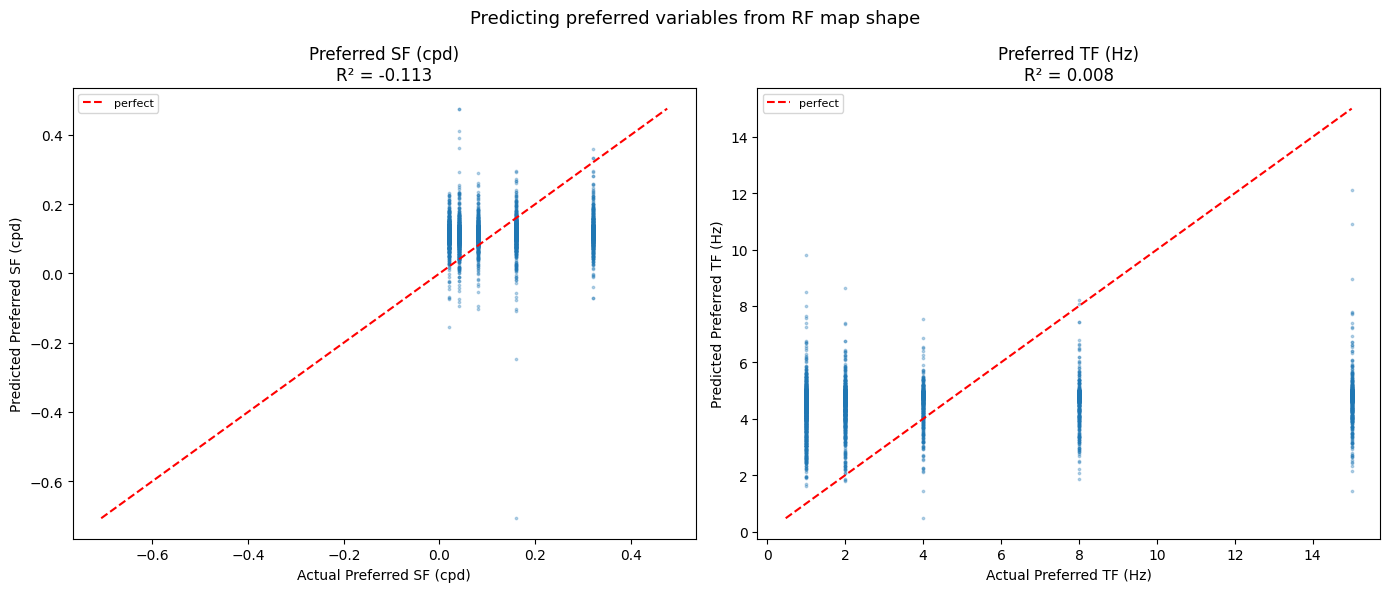

In [3]:
targets_reg = {
    'pref_sf_gaussian_snapped': 'Preferred SF (cpd)',
    'pref_tf_gaussian_snapped': 'Preferred TF (Hz)',
}

X_train, X_test, idx_train, idx_test = train_test_split(
    X, np.arange(len(X)), test_size=0.2, random_state=42
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

fig, axes = plt.subplots(1, len(targets_reg), figsize=(7 * len(targets_reg), 6))

for ax, (col, label) in zip(axes, targets_reg.items()):
    y = df[col].values.astype(np.float32)
    y_train, y_test = y[idx_train], y[idx_test]

    # drop NaNs from training
    valid = np.isfinite(y_train)
    reg = MLPRegressor(hidden_layer_sizes=(256, 256), max_iter=1000, random_state=42,
                       early_stopping=True, validation_fraction=0.1, n_iter_no_change=15)
    reg.fit(X_train_s[valid], y_train[valid])

    valid_test = np.isfinite(y_test)
    y_pred = reg.predict(X_test_s[valid_test])
    r2 = r2_score(y_test[valid_test], y_pred)

    ax.scatter(y_test[valid_test], y_pred, s=3, alpha=0.3, rasterized=True)
    lims = [min(y_test[valid_test].min(), y_pred.min()),
            max(y_test[valid_test].max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='perfect')
    ax.set_xlabel(f"Actual {label}")
    ax.set_ylabel(f"Predicted {label}")
    ax.set_title(f"{label}\nR² = {r2:.3f}")
    ax.legend(fontsize=8)

fig.suptitle("Predicting preferred variables from RF map shape", fontsize=13)
fig.tight_layout()
plt.show()

## Predict preferred orientation (classification)
Orientation is discrete (8 directions) so we treat it as a classification problem.

Orientation accuracy: 0.297  (chance = 0.250,  n classes = 4)


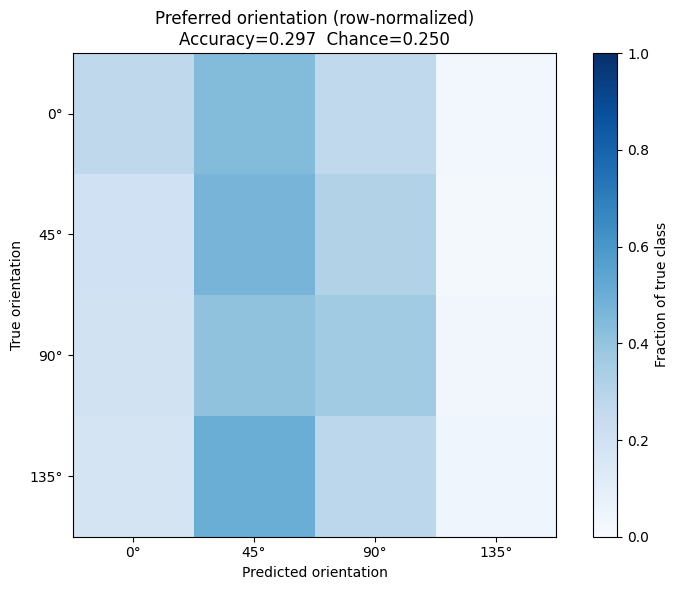

In [4]:
y_ori = df['pref_ori'].values
valid_ori = np.isfinite(y_ori)

X_ori   = X[valid_ori]
y_ori   = y_ori[valid_ori].astype(int)
ori_labels = sorted(np.unique(y_ori))
n_ori = len(ori_labels)

X_tr_o, X_te_o, y_tr_o, y_te_o = train_test_split(
    X_ori, y_ori, test_size=0.2, random_state=42, stratify=y_ori
)
sc_o    = StandardScaler()
X_tr_o  = sc_o.fit_transform(X_tr_o)
X_te_o  = sc_o.transform(X_te_o)

clf_ori = MLPClassifier(hidden_layer_sizes=(256, 256), max_iter=1000, random_state=42,
                        early_stopping=True, validation_fraction=0.1, n_iter_no_change=15)
clf_ori.fit(X_tr_o, y_tr_o)

acc = clf_ori.score(X_te_o, y_te_o)
print(f"Orientation accuracy: {acc:.3f}  (chance = {1/n_ori:.3f},  n classes = {n_ori})")

# Confusion matrix
cm = confusion_matrix(y_te_o, clf_ori.predict(X_te_o), labels=ori_labels, normalize='true')
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n_ori))
ax.set_xticklabels([f"{o}°" for o in ori_labels])
ax.set_yticks(range(n_ori))
ax.set_yticklabels([f"{o}°" for o in ori_labels])
ax.set_xlabel("Predicted orientation")
ax.set_ylabel("True orientation")
ax.set_title(f"Preferred orientation (row-normalized)\nAccuracy={acc:.3f}  Chance={1/n_ori:.3f}")
plt.colorbar(im, ax=ax, label="Fraction of true class")
fig.tight_layout()
plt.show()